<a href="https://colab.research.google.com/github/Mueez-lab/FaceRecoginitionSystem/blob/main/FaceRecoginitionSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA # Principal Component Analysis (PCA) to reduce the dimensionality of a dataset and visualize how much variance each principal component captures.
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [6]:
from google.colab import files
uploaded = files.upload()


Saving face_data.csv to face_data.csv


In [7]:
df = pd.read_csv('face_data.csv')
df

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669422,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364,39
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587,39
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669422,0.673554,0.702479,...,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083,39
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306,39


In [8]:
labels = df['target']
pixels = df.drop(['target'], axis=1)

In [9]:
def show_original_images (pixels):
  fig,axes = plt.subplots(5, 5, figsize=(10, 10))
  for i,ax in enumerate(axes.flat):
    ax.imshow(np.array(pixels.iloc[i]).reshape(64, 64), cmap='gray')
    ax.axis('off')
  plt.show()

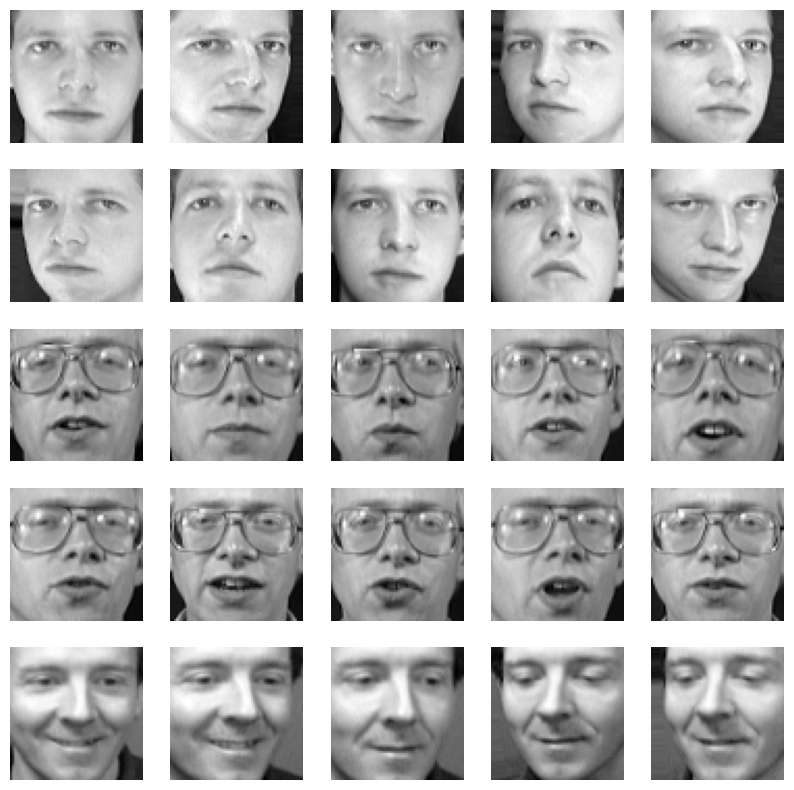

In [10]:
original_images = show_original_images(pixels)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(pixels, labels, test_size=0.2, random_state=42)

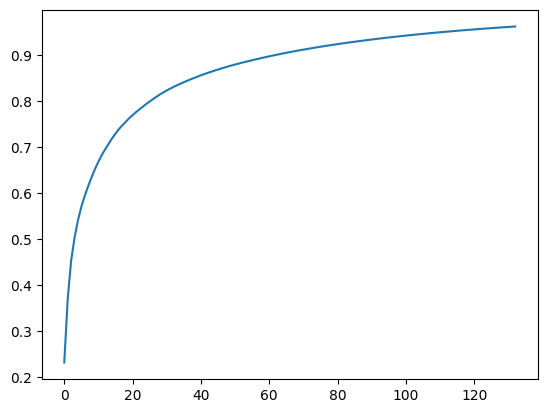

In [31]:
# Think of it like summarizing a 5000-word article in just 200 key bullet points that preserve the essence of the text.
# These 200 directions capture the most important patterns (variance) in the data.
pca = PCA(n_components=133).fit(x_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_)) #How much of the original data's variance is captured by each of the 200 components?
plt.show()

In [30]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 because index starts at 0
print(f"Number of components to retain 95% variance: {n_components_95}") # update 200 to 133

Number of components to retain 95% variance: 113


In [32]:
def show_eigenfaces(pca):
  eigenfaces = pca.components_.reshape((133, 64, 64))
  fig, axes = plt.subplots(5, 5, figsize=(10, 10))
  for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.axis('off')

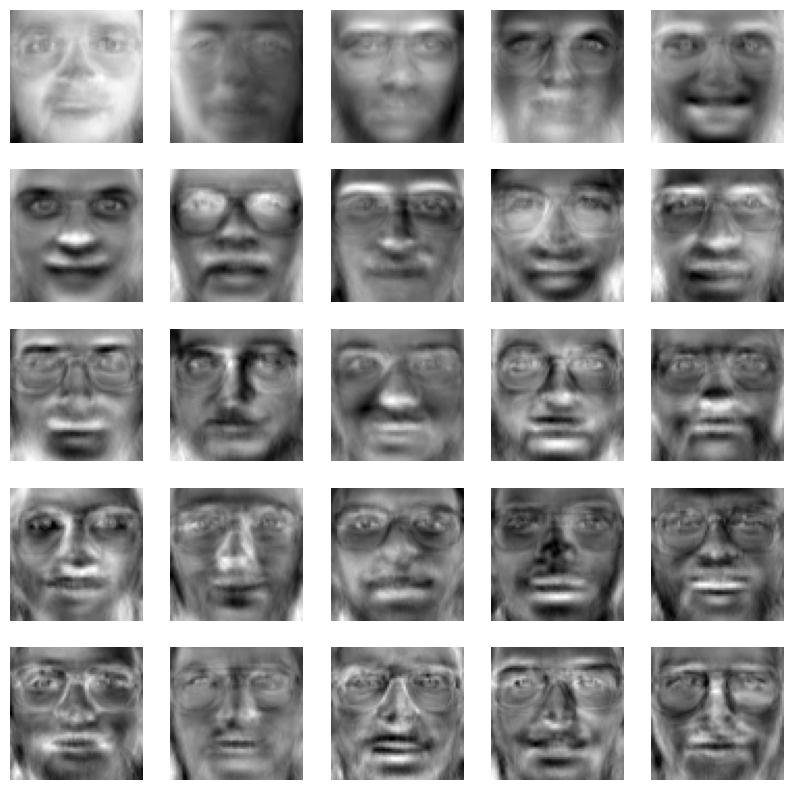

In [35]:
show_eigenfaces(pca) # White part shows the maximun variance

In [34]:
# Project Training data to pcs

#It converts your original data (like flattened 64×64 = 4096 pixel images) into a lower-dimensional representation, typically something like 60, 100, or 200 dimensions.
x_train_pca = pca.transform(x_train)
x_test_pca = pca.transform(x_test)

# fit()	Learns the principal components from data	🧠 Training step
# transform()	Applies those components to reduce data	🔁 Data transformation step

In [84]:
clf = SVC(kernel='rbf', C=1000, gamma=0.001) # C is how much error is allowed
clf = clf.fit(x_train_pca,y_train)

In [85]:
# Perform testing and get the classification report
y_pred = clf.predict(x_test_pca)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       0.75      1.00      0.86         3
          18       1.00      1.00      1.00         1
          19       1.00    

In [86]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(clf, x_train_pca, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average CV score:", cv_scores.mean())


Cross-validation scores: [0.9375   0.921875 0.953125 0.984375 0.984375]
Average CV score: 0.95625


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
